In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv(
    "../data/scenario_a/scenario_a_train.csv",
    parse_dates=["date_week"],
)

train_df.info()
display(train_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date_week            130 non-null    datetime64[us]
 1   revenue              130 non-null    float64       
 2   tv_spend             130 non-null    float64       
 3   google_search_spend  130 non-null    float64       
 4   tiktok_spend         130 non-null    float64       
 5   promotion            130 non-null    int64         
 6   time_index           130 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 7.2 KB


,date_week,revenue,tv_spend,google_search_spend,tiktok_spend,promotion,time_index
count,130,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,2024-03-28 12:00:00,1259.297383,30.853286,44.620516,22.984453,0.153846,0.416129
min,2023-01-02 00:00:00,1101.738690,0.000000,24.136481,2.410062,0.000000,0.000000
25%,2023-08-15 18:00:00,1205.323997,0.000000,38.335832,12.051439,0.000000,0.208065
50%,2024-03-28 12:00:00,1255.043204,21.929768,43.956118,19.211222,0.000000,0.416129
75%,2024-11-09 06:00:00,1304.715789,52.242300,49.750077,31.715864,0.000000,0.624194
max,2025-06-23 00:00:00,1433.424416,120.000000,65.699729,60.000000,1.000000,0.832258
std,NaN,72.107620,34.272816,8.806647,14.903062,0.362197,0.243044


TV spend is campaign-like, with many zero-spend weeks and occasional large bursts of investment.
TikTok spend is more variable than Search, but it remains positive throughout the training period

In [2]:
assert len(train_df) == 130
assert not train_df.isna().any().any()
assert train_df["date_week"].is_monotonic_increasing
assert (train_df["revenue"] > 0).all()

channels = [
    "tv_spend",
    "google_search_spend",
    "tiktok_spend",
]

assert (train_df[channels] >= 0).all().all()

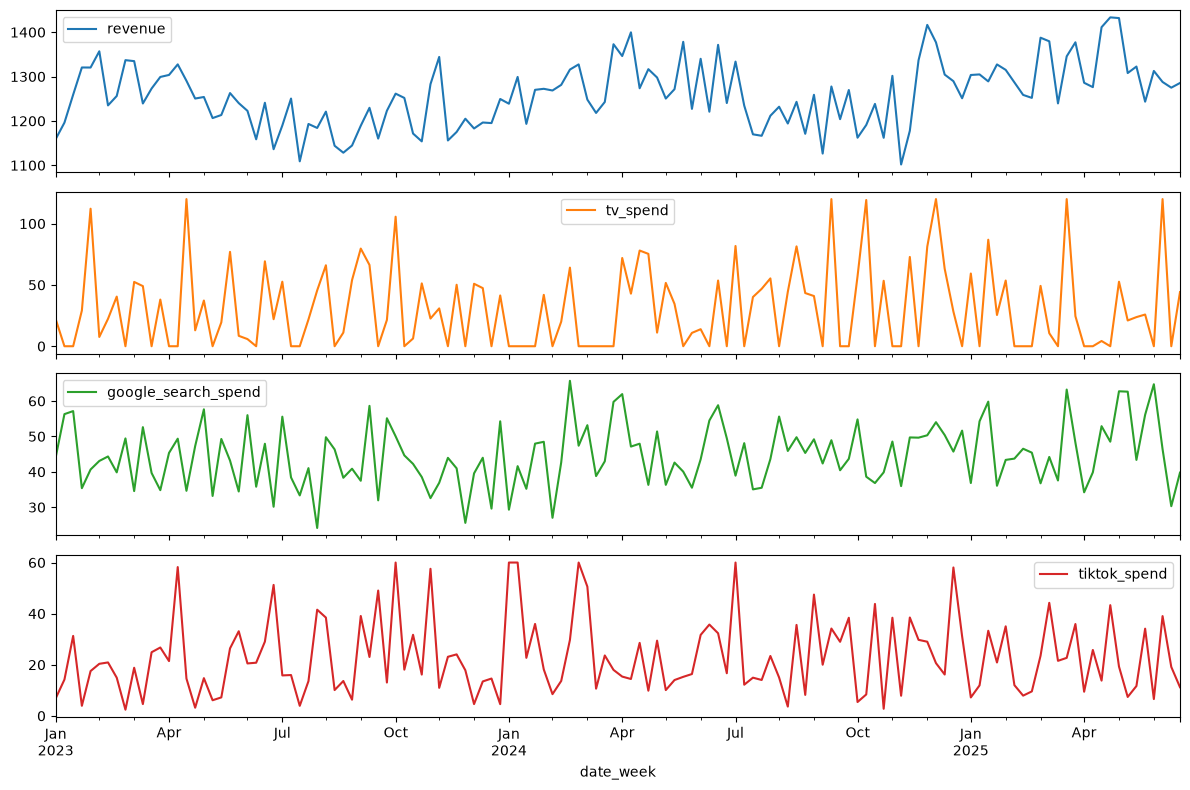

In [3]:
train_df.set_index("date_week")[
    ["revenue", *channels]
].plot(
    subplots=True,
    figsize=(12, 8),
)

plt.tight_layout()
plt.show()

In [4]:
display(
    train_df[
        [
            "revenue",
            *channels,
            "promotion",
            "time_index",
        ]
    ].corr().round(2)
)

,revenue,tv_spend,google_search_spend,tiktok_spend,promotion,time_index
revenue,1.00,0.13,0.32,0.18,0.50,0.31
tv_spend,0.13,1.00,0.16,0.04,-0.17,0.06
google_search_spend,0.32,0.16,1.00,-0.01,0.12,0.19
tiktok_spend,0.18,0.04,-0.01,1.00,0.04,0.06
promotion,0.50,-0.17,0.12,0.04,1.00,-0.01
time_index,0.31,0.06,0.19,0.06,-0.01,1.00


The dataset contains 130 consecutive weekly observations with no missing
values or invalid spend. TV and TikTok are more campaign-like，meaning the budget is concentrated in specific flight periods rather than being spent continuously every week. Google Search is relatively always-on. I also inspected channel and control correlations because strong correlation may weaken attribution identifiability.
